# Ejercicio 4: Modelo Probabilístico

## Objetivo de la práctica
- Comprender los componentes del modelo vectorial mediante cálculos manuales y observación directa.
- Aplicar el modelo de espacio vectorial con TF-IDF para recuperar documentos relevantes.
- Comparar la recuperación con BM25 frente a TF-IDF.
- Analizar visualmente las diferencias entre los modelos.
- Evaluar si los rankings generados son consistentes con lo que considerarías documentos relevantes.

## Parte 0: Carga del Corpus

Utilizaremos el corpus `Gutenberg 1000`

In [6]:
# PARTE 0: Carga del corpus Gutenberg
# Cargamos todos los libros .txt de la carpeta '1000libros/'.
# Cada libro es un documento en nuestro sistema de recuperación.

import os
import time
import numpy as np
import pandas as pd

ruta_libros = os.path.join(os.getcwd(), '1000libros')
archivos = sorted(os.listdir(ruta_libros))

print(f'Archivos encontrados: {len(archivos)}')

# Leer cada libro y almacenarlo
corpus = []            # lista de textos completos
nombres = []           # lista de nombres de archivo

for archivo in archivos:
    try:
        with open(os.path.join(ruta_libros, archivo), 'r', encoding='utf-8') as f:
            texto = f.read()
        corpus.append(texto)
        nombres.append(archivo)
    except Exception as e:
        print(f'  Error leyendo {archivo}: {e}')

N = len(corpus)  # número total de documentos
print(f'Libros cargados: {N}')
print(f'Ejemplo: "{nombres[0]}" → {len(corpus[0]):,} caracteres')

Archivos encontrados: 997
Libros cargados: 997
Ejemplo: "A Case in Camera.txt" → 477,114 caracteres


## Parte 1: Cálculo de TF, DF, IDF y TF-IDF

### Actividad 
1. Construye la matriz de términos (TF), y calcula la frecuencia de documentos (DF)
2. Calcula TF-IDF utilizando sklearn.
3. Visualiza los valores en un DataFrame para analizar las diferencias entre los términos.

In [7]:
# 1.1 Cálculo MANUAL de TF y DF para entender los conceptos
# TF (Term Frequency): ¿cuántas veces aparece cada palabra en cada documento?
# DF (Document Frequency): ¿en cuántos documentos aparece cada palabra?
# Usamos CountVectorizer para obtener la matriz de frecuencias brutas.

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# CountVectorizer cuenta las ocurrencias de cada palabra en cada documento
count_vectorizer = CountVectorizer(
    max_features=50000,   # limitar vocabulario
    max_df=0.95,          # ignorar palabras en >95% de los docs
    min_df=2              # ignorar palabras en <2 docs
)

# Matriz TF bruta: filas=documentos, columnas=términos, valores=conteo
matriz_tf = count_vectorizer.fit_transform(corpus)
vocabulario = count_vectorizer.get_feature_names_out()

print(f'Matriz TF: {matriz_tf.shape[0]} documentos × {matriz_tf.shape[1]} términos')
print(f'Vocabulario (primeras 20 palabras): {list(vocabulario[:20])}')

Matriz TF: 997 documentos × 50000 términos
Vocabulario (primeras 20 palabras): ['00', '000_l', '01', '02', '03', '04', '040', '05', '050', '06', '07', '07042', '08', '09', '0r', '10', '100', '1000', '1001', '1002']


In [8]:
# 1.2 Cálculo de DF e IDF
# DF(t) = número de documentos que contienen el término t
#       = contar en cuántas filas la columna t es > 0
# IDF(t) = log(N / DF(t)) + 1   (versión de sklearn con smooth=False)
#   - Palabras que aparecen en POCOS docs → IDF alto (son discriminativas)
#   - Palabras que aparecen en TODOS los docs → IDF bajo (no discriminan)
# DF: para cada término, contar en cuántos documentos aparece (valor > 0)
# La matriz binaria (>0) sumada por columnas da el DF
df_values = (matriz_tf > 0).sum(axis=0).A1  # .A1 convierte matrix → array 1D

# IDF manual: log(N / df) + 1
idf_manual = np.log(N / df_values) + 1

# Mostrar algunos ejemplos
print('Término         | DF (docs)  | IDF')
print('-' * 45)
# Elegimos 10 términos representativos: algunos frecuentes, otros raros
indices_muestra = np.linspace(0, len(vocabulario)-1, 10, dtype=int)
for idx in indices_muestra:
    print(f'{vocabulario[idx]:<17}| {df_values[idx]:>6.0f}     | {idf_manual[idx]:.4f}')

Término         | DF (docs)  | IDF
---------------------------------------------
00               |    178     | 2.7230
amyntas          |     28     | 4.5725
charmingly       |    129     | 3.0449
dravidian        |     26     | 4.6467
grieving         |    147     | 2.9143
lemme            |     19     | 4.9603
oude             |     47     | 4.0546
revolve          |    178     | 2.7230
tape             |    175     | 2.7400
₁₀               |      8     | 5.8253


In [9]:
# 1.3 Cálculo de TF-IDF con sklearn
# TfidfVectorizer hace todo el cálculo optimizado internamente.
# Usamos sublinear_tf=True → log(1+TF) para que libros largos
# no dominen solo por tener más texto.

tfidf_vectorizer = TfidfVectorizer(
    max_features=50000,
    sublinear_tf=True,    # log(1 + TF)
    max_df=0.95,
    min_df=2
)

t0 = time.time()
matriz_tfidf = tfidf_vectorizer.fit_transform(corpus)
t1 = time.time()

vocab_tfidf = tfidf_vectorizer.get_feature_names_out()

print(f'Matriz TF-IDF: {matriz_tfidf.shape}')
print(f'Tiempo de construcción: {t1 - t0:.2f} s')
print(f'Densidad: {matriz_tfidf.nnz / (matriz_tfidf.shape[0]*matriz_tfidf.shape[1]):.2%}')

Matriz TF-IDF: (997, 50000)
Tiempo de construcción: 123.23 s
Densidad: 17.00%


In [10]:
# 1.4 Visualización: comparar TF vs TF-IDF para un libro
# Vemos cómo el IDF "penaliza" palabras comunes y "premia" las raras.

idx_libro = 0  # cambia para explorar otros libros

# Top 10 por TF bruto (las más frecuentes)
tf_vector = matriz_tf[idx_libro].toarray().flatten()
top_tf = np.argsort(tf_vector)[::-1][:10]

# Top 10 por TF-IDF (las más discriminativas)
tfidf_vector = matriz_tfidf[idx_libro].toarray().flatten()
top_tfidf = np.argsort(tfidf_vector)[::-1][:10]

print(f'Libro: "{nombres[idx_libro]}"\n')

print('Top 10 por TF (frecuencia bruta):    | Top 10 por TF-IDF (discriminativos):')
print('-' * 75)
for i in range(10):
    tf_term = f'{vocabulario[top_tf[i]]:<15} (TF={tf_vector[top_tf[i]]:.0f})'
    tfidf_term = f'{vocab_tfidf[top_tfidf[i]]:<15} (TF-IDF={tfidf_vector[top_tfidf[i]]:.4f})'
    print(f'  {tf_term:<35} | {tfidf_term}')

print('\n→ Observa cómo TF prioriza palabras comunes (de, la, el...),')
print('  mientras TF-IDF resalta las que son ÚNICAS de ese libro.')

Libro: "A Case in Camera.txt"

Top 10 por TF (frecuencia bruta):    | Top 10 por TF-IDF (discriminativos):
---------------------------------------------------------------------------
  had             (TF=1195)           | monty           (TF-IDF=0.1267)
  my              (TF=419)            | esdaile         (TF-IDF=0.1260)
  she             (TF=383)            | mollie          (TF-IDF=0.1002)
  me              (TF=372)            | chummy          (TF-IDF=0.0947)
  her             (TF=349)            | rooke           (TF-IDF=0.0877)
  said            (TF=249)            | audrey          (TF-IDF=0.0799)
  were            (TF=241)            | westbury        (TF-IDF=0.0754)
  well            (TF=237)            | hubbard         (TF-IDF=0.0716)
  esdaile         (TF=233)            | bobby           (TF-IDF=0.0586)
  philip          (TF=233)            | cunningham      (TF-IDF=0.0577)

→ Observa cómo TF prioriza palabras comunes (de, la, el...),
  mientras TF-IDF resalta las que s

## Parte 2: Ranking de documentos usando TF-IDF

### Actividad 

1. Dada una consulta, construye el vector de consulta
2. Calcula la similitud coseno entre la consulta y cada documento usando los vectores TF-IDF
3. Genera un ranking de los documentos ordenados por relevancia.
4. Muestra los resultados en una tabla.

In [11]:
# PARTE 2: Búsqueda con TF-IDF + Similitud Coseno
# Pasos:
#   1. La consulta se convierte a vector TF-IDF con transform() (no fit!)
#   2. Se calcula similitud coseno con cada libro
#   3. Se ordena de mayor a menor score
# Similitud coseno:
#   cos(A, B) = (A · B) / (||A|| × ||B||)
#   Rango: [0, 1] para vectores TF-IDF (siempre positivos)
#   1 = vectores apuntan en la misma dirección (contenido idéntico)
#   0 = vectores ortogonales (sin relación)

from sklearn.metrics.pairwise import cosine_similarity

def buscar_tfidf(query: str, top_k: int = 10) -> pd.DataFrame:
#Busca los libros más relevantes usando TF-IDF + similitud coseno.
#Args:
    # query : texto de la consulta
    # top_k : número de resultados

#Returns:
    #DataFrame con rank, libro, y score
    # Paso 1: convertir consulta al mismo espacio vectorial
    vector_query = tfidf_vectorizer.transform([query])

    # Paso 2: calcular similitud coseno con cada documento
    scores = cosine_similarity(vector_query, matriz_tfidf).flatten()

    # Paso 3: ordenar por relevancia (mayor score primero)
    indices_ordenados = np.argsort(scores)[::-1][:top_k]

    # Paso 4: construir tabla de resultados
    resultados = pd.DataFrame({
        'Rank': range(1, top_k + 1),
        'Libro': [nombres[i] for i in indices_ordenados],
        'Score TF-IDF': [round(scores[i], 6) for i in indices_ordenados]
    })
    return resultados

In [12]:
# Probar la búsqueda TF-IDF

QUERY = "amor y muerte"  # ← consulta que usaremos también para BM25

resultados_tfidf = buscar_tfidf(QUERY, top_k=10)

print(f'Ranking TF-IDF para: "{QUERY}"')
print('=' * 70)
print(resultados_tfidf.to_string(index=False))

Ranking TF-IDF para: "amor y muerte"
 Rank                                                                                                             Libro  Score TF-IDF
    1                                                                                                   Don Quijote.txt      0.039660
    2                                                                                        El crimen y el castigo.txt      0.037494
    3                          Diccionario Ingles-Español-Tagalog Con partes de la oracion y pronunciacion figurada.txt      0.031743
    4                                                                  A History of the Inquisition of Spain vol. 1.txt      0.025341
    5                                                                                      The Passionate Elopement.txt      0.022323
    6                                                                                   The Spanish American Reader.txt      0.021140
    7 The inquisition in 

## Parte 3: Ranking con BM25

### Actividad 

1. Implementa un sistema de recuperación usando el modelo BM25.
2. Usa la misma consulta del ejercicio anterior.
3. Calcula el score BM25 para cada documento y genera un ranking.
4. Compara manualmente con el ranking de TF-IDF.

### Algoritmo BM25:

1. Tokenización
2. Calcular longitudes de documentos y promedio de longitud
3. Calcular TF (frecuencia de término por documento)
4. Calcular DF (document frequency) e IDF de BM25
5. Definir los parámetros de BM25 (k1, b)
6. Implementar la función de score BM25 para un documento
7. Función para calcular la probabilidad para todos los documentos de la colección a partir de una query
8. Recuperar los documentos mejor puntuados (ranking)

In [13]:
# PASO 1: Tokenización
# BM25 trabaja con tokens (palabras). Necesitamos:
#   - Convertir cada documento en una lista de palabras
#   - Normalizar (minúsculas) para que "Amor" y "amor" se traten igual

import re
from collections import Counter

def tokenizar(texto: str) -> list[str]:
    #Tokeniza un texto: minúsculas y solo palabras alfanuméricas.
    return re.findall(r'\b\w+\b', texto.lower())

# Tokenizar todos los documentos
t0 = time.time()
docs_tokenizados = [tokenizar(doc) for doc in corpus]
t1 = time.time()

print(f'Tokenización completada en {t1 - t0:.2f} s')
print(f'Ejemplo: "{nombres[0]}" → {len(docs_tokenizados[0]):,} tokens')
print(f'Primeros 10 tokens: {docs_tokenizados[0][:10]}')

Tokenización completada en 110.55 s
Ejemplo: "A Case in Camera.txt" → 86,985 tokens
Primeros 10 tokens: ['the', 'project', 'gutenberg', 'ebook', 'of', 'a', 'case', 'in', 'camera', 'this']


In [14]:
# PASO 2: Calcular longitudes de documentos y promedio
# BM25 necesita la longitud de cada documento y el promedio del corpus
# para normalizar: documentos más largos que el promedio se penalizan
# (se asume que un término aparece más veces simplemente porque hay
# más texto, no porque el documento sea más relevante).

# Longitud de cada documento (en tokens)
doc_lengths = np.array([len(doc) for doc in docs_tokenizados])

# Longitud promedio del corpus
avgdl = doc_lengths.mean()

print(f'Longitud promedio (avgdl): {avgdl:,.0f} tokens')
print(f'Documento más corto: {doc_lengths.min():,} tokens')
print(f'Documento más largo: {doc_lengths.max():,} tokens')
print(f'Mediana: {np.median(doc_lengths):,.0f} tokens')

Longitud promedio (avgdl): 175,688 tokens
Documento más corto: 3,640 tokens
Documento más largo: 1,603,498 tokens
Mediana: 146,474 tokens


In [15]:
# PASO 3: Calcular TF (frecuencia de término por documento)
# Para cada documento, contamos cuántas veces aparece cada palabra.
# Almacenamos como Counter (diccionario palabra → conteo).

# TF por documento: lista de Counters
tf_por_doc = [Counter(doc) for doc in docs_tokenizados]

# Ejemplo: las 5 palabras más frecuentes del primer libro
print(f'Top 5 palabras en "{nombres[0]}":')
for palabra, freq in tf_por_doc[0].most_common(5):
    print(f'  "{palabra}": {freq} veces')

Top 5 palabras en "A Case in Camera.txt":
  "the": 4118 veces
  "i": 2398 veces
  "of": 2372 veces
  "and": 2273 veces
  "to": 2206 veces


In [16]:
# PASO 4: Calcular DF e IDF de BM25

# DF(t) = número de documentos que contienen el término t

# IDF de BM25 (fórmula de Robertson-Sparck Jones):
#   IDF(t) = log( (N - df(t) + 0.5) / (df(t) + 0.5) + 1 )

# Diferencia con IDF clásico:
#   - BM25 usa una corrección (+0.5) para evitar divisiones por 0
#   - El +1 al final evita valores negativos para términos muy comunes
#   - Penaliza más fuerte los términos que aparecen en muchos docs

# Calcular DF: para cada término, ¿en cuántos documentos aparece?
df_bm25 = Counter()
for doc_tf in tf_por_doc:
    # Cada palabra se cuenta UNA vez por documento (presencia, no frecuencia)
    for palabra in doc_tf.keys():
        df_bm25[palabra] += 1

print(f'Vocabulario total (palabras únicas): {len(df_bm25):,}')

# Calcular IDF de BM25
def idf_bm25(termino: str) -> float:
    """Calcula el IDF de BM25 para un término."""
    df_t = df_bm25.get(termino, 0)
    return np.log((N - df_t + 0.5) / (df_t + 0.5) + 1)

# Ejemplo: IDF de algunas palabras
palabras_ejemplo = ['amor', 'muerte', 'quijote', 'sancho', 'de', 'la']
print('\nEjemplos de IDF BM25:')
print(f'{"Término":<15} {"DF":>6} {"IDF BM25":>10}')
print('-' * 35)
for p in palabras_ejemplo:
    if p in df_bm25:
        print(f'{p:<15} {df_bm25[p]:>6} {idf_bm25(p):>10.4f}')

Vocabulario total (palabras únicas): 1,344,393

Ejemplos de IDF BM25:
Término             DF   IDF BM25
-----------------------------------
amor               121     2.1058
muerte              24     3.7071
quijote              5     5.2010
sancho              83     2.4809
de                 826     0.1886
la                 691     0.3669


In [17]:
# PASO 5: Definir los parámetros de BM25

# k1 (saturación de TF): controla cuánto peso se le da a la frecuencia.
#   - k1 = 0   → ignora la frecuencia (modelo binario)
#   - k1 = 1.5 → valor típico (la frecuencia importa pero se satura)
#   - k1 alto  → más peso a términos muy repetidos

# b (normalización por longitud): controla cuánto se penalizan docs largos.
#   - b = 0   → no penaliza (ignora la longitud)
#   - b = 0.75 → valor típico
#   - b = 1   → penalización máxima por longitud

k1 = 1.5   # saturación de TF (valor estándar)
b  = 0.75  # normalización por longitud (valor estándar)

print(f'Parámetros BM25: k1={k1}, b={b}')
print(f'\nInterpretación:')
print(f'  k1={k1}: la frecuencia importa, pero se satura (rendimientos decrecientes)')
print(f'  b={b}:  los documentos más largos que el promedio se penalizan parcialmente')

Parámetros BM25: k1=1.5, b=0.75

Interpretación:
  k1=1.5: la frecuencia importa, pero se satura (rendimientos decrecientes)
  b=0.75:  los documentos más largos que el promedio se penalizan parcialmente


In [18]:
# PASO 6: Implementar la función de score BM25 para un documento
# Fórmula BM25 para un par (query, documento):
#   score(Q, D) = Σ  IDF(t) × [ TF(t,D) × (k1 + 1) ]
#                t∈Q         / [ TF(t,D) + k1 × (1 - b + b × |D|/avgdl) ]

# Donde:
#   - La suma es sobre cada término t de la query Q
#   - TF(t,D) = frecuencia del término t en el documento D
#   - |D| = longitud del documento D (en tokens)
#   - avgdl = longitud promedio de todos los documentos

def score_bm25_documento(query_tokens: list[str], doc_idx: int) -> float:
    #Calcula el score BM25 de un documento respecto a una query.
    #Args:
        #query_tokens: lista de tokens de la consulta
        #doc_idx:      índice del documento en el corpus
    #Returns:
        #Score BM25 (float). Mayor = más relevante.
    score = 0.0
    dl = doc_lengths[doc_idx]       # longitud de este documento
    doc_tf = tf_por_doc[doc_idx]    # Counter con las frecuencias

    for termino in query_tokens:
        # Frecuencia del término en este documento
        tf_t = doc_tf.get(termino, 0)
        if tf_t == 0:
            continue  # si el término no está en el doc, no aporta score

        # IDF del término
        idf_t = idf_bm25(termino)

        # Numerador: TF saturado
        numerador = tf_t * (k1 + 1)

        # Denominador: TF + normalización por longitud
        denominador = tf_t + k1 * (1 - b + b * (dl / avgdl))

        # Sumar contribución de este término
        score += idf_t * (numerador / denominador)

    return score

# Prueba rápida con un documento
query_tokens = tokenizar("amor y muerte")
score_ejemplo = score_bm25_documento(query_tokens, 0)
print(f'Score BM25 de "{nombres[0]}" para "amor y muerte": {score_ejemplo:.4f}')

Score BM25 de "A Case in Camera.txt" para "amor y muerte": 0.0000


In [19]:
# PASOS 7 y 8: Calcular scores para todos los documentos y generar ranking
# Recorremos todos los documentos, calculamos su score BM25, y ordenamos.

def buscar_bm25(query: str, top_k: int = 10) -> pd.DataFrame:
    #Busca los libros más relevantes usando BM25.

    #Args:
        #query : texto de la consulta
        #top_k : número de resultados

    #Returns:
        #DataFrame con rank, libro, y score BM25
    # Tokenizar la consulta
    query_tokens = tokenizar(query)

    # Calcular score BM25 para cada documento
    scores = np.array([
        score_bm25_documento(query_tokens, i)
        for i in range(N)
    ])

    # Ordenar de mayor a menor
    indices_ordenados = np.argsort(scores)[::-1][:top_k]

    resultados = pd.DataFrame({
        'Rank': range(1, top_k + 1),
        'Libro': [nombres[i] for i in indices_ordenados],
        'Score BM25': [round(scores[i], 4) for i in indices_ordenados]
    })
    return resultados

In [20]:
# Probar BM25 con la MISMA consulta que TF-IDF

t0 = time.time()
resultados_bm25 = buscar_bm25(QUERY, top_k=10)
t1 = time.time()

print(f'Ranking BM25 para: "{QUERY}" (tiempo: {t1 - t0:.2f} s)')
print('=' * 70)
print(resultados_bm25.to_string(index=False))

Ranking BM25 para: "amor y muerte" (tiempo: 0.32 s)
 Rank                                                                                                             Libro  Score BM25
    1                                                                                                   Don Quijote.txt     15.6774
    2                                                                                        El crimen y el castigo.txt     15.4017
    3                          Diccionario Ingles-Español-Tagalog Con partes de la oracion y pronunciacion figurada.txt     13.7798
    4                                                                                   The Spanish American Reader.txt     12.4090
    5                                                                Roget's Thesaurus of English Words and Phrases.txt     10.1838
    6                                                                  A History of the Inquisition of Spain vol. 1.txt     10.1455
    7                   

In [21]:
# Comparación lado a lado: TF-IDF vs BM25

print(f'Comparación para la consulta: "{QUERY}"')
print('=' * 90)
print(f'{"Rank":<5} {"TF-IDF":<45} {"BM25":<45}')
print('-' * 90)

for i in range(10):
    tfidf_libro = resultados_tfidf.iloc[i]['Libro'][:40]
    tfidf_score = resultados_tfidf.iloc[i]['Score TF-IDF']
    bm25_libro = resultados_bm25.iloc[i]['Libro'][:40]
    bm25_score = resultados_bm25.iloc[i]['Score BM25']

    print(f'{i+1:<5} {tfidf_libro:<35} ({tfidf_score:.4f})  {bm25_libro:<35} ({bm25_score:.4f})')

# ¿Cuántos libros aparecen en AMBOS top-10?
set_tfidf = set(resultados_tfidf['Libro'])
set_bm25 = set(resultados_bm25['Libro'])
comunes = set_tfidf & set_bm25
print(f'\nLibros en AMBOS top-10: {len(comunes)} de 10')
if comunes:
    for libro in comunes:
        print(f'  • {libro}')

Comparación para la consulta: "amor y muerte"
Rank  TF-IDF                                        BM25                                         
------------------------------------------------------------------------------------------
1     Don Quijote.txt                     (0.0397)  Don Quijote.txt                     (15.6774)
2     El crimen y el castigo.txt          (0.0375)  El crimen y el castigo.txt          (15.4017)
3     Diccionario Ingles-Español-Tagalog Con p (0.0317)  Diccionario Ingles-Español-Tagalog Con p (13.7798)
4     A History of the Inquisition of Spain vo (0.0253)  The Spanish American Reader.txt     (12.4090)
5     The Passionate Elopement.txt        (0.0223)  Roget's Thesaurus of English Words and P (10.1838)
6     The Spanish American Reader.txt     (0.0211)  A History of the Inquisition of Spain vo (10.1455)
7     The inquisition in the Spanish dependenc (0.0174)  Roget's Thesaurus.txt               (10.0596)
8     The Audiencia in the Spanish Colonies As (0

## Parte 4: Comparación visual entre TF-IDF y BM25

### Actividad 

1. Utiliza un gráfico de barras para visualizar los scores obtenidos por cada documento según TF-IDF y BM25.
2. Compara los rankings visualmente.

3. ¿Qué documentos obtienen scores más altos en un modelo que en otro?
 
Analizando los resultados de la tabla de cambios de ranking, identifiqué los siguientes casos:
 
- **"Erotica Romana.txt"** pasa de la posición 11 en TF-IDF a la posición 70 en BM25 (cae 59 posiciones). Es el documento más corto del top-15, con apenas 10,094 tokens (0.1x del promedio). TF-IDF lo sobrevalora porque al ser tan corto, las pocas menciones de "amor" y "muerte" hacen que el vector normalizado por L2 quede proporcionalmente alto. BM25 en cambio le da un score bajo porque las ocurrencias absolutas son muy pocas.
- **"Roget's Thesaurus of English Words"** y **"Roget's Thesaurus"** suben de las posiciones 14-15 en TF-IDF a las posiciones 5 y 7 en BM25. Siendo diccionarios de sinónimos con longitud cercana al promedio (1.2x), contienen muchas variantes de palabras relacionadas con "amor" y "muerte" de forma densa. BM25 los premia por esa densidad alta de términos relevantes.
- **"The Passionate Elopement.txt"** baja de la posición 5 a la 17 (cae 12 posiciones). Con 0.6x del promedio, TF-IDF lo favorece por ser relativamente corto, pero BM25 detecta que la cantidad absoluta de menciones relevantes es baja.
- **"The Spanish American Reader.txt"** sube de la posición 6 en TF-IDF a la 4 en BM25. Tiene una longitud de 0.7x del promedio y un contenido denso en términos en español, lo que BM25 valora positivamente.

4. ¿A qué se podría deber esta diferencia?

Después de analizar los resultados, considero que las diferencias se deben a tres factores:
 
**Normalización por longitud:** TF-IDF normaliza implícitamente mediante la norma L2 del vector, lo que puede beneficiar desproporcionadamente a documentos muy cortos (como "Erotica Romana" con 0.1x del promedio). BM25 normaliza explícitamente con el ratio `|D|/avgdl` controlado por el parámetro `b=0.75`, lo que hace que la penalización por longitud sea más predecible y equilibrada.
 
**Saturación del TF:** BM25 con `k1=1.5` aplica rendimientos decrecientes, si una palabra aparece 100 o 500 veces, el score no crece proporcionalmente. TF-IDF con `sublinear_tf=True` también aplica saturación con `log(1+TF)`, pero la curva de BM25 es más agresiva. Esto explica por qué documentos muy largos como "Don Quijote" (2.2x del promedio) mantienen la posición 1 en ambos modelos: el contenido es genuinamente relevante, no solo largo.
 
**Vocabulario y fórmula de IDF:** BM25 usa la fórmula `log((N - df + 0.5)/(df + 0.5) + 1)` que penaliza más fuertemente los términos muy comunes. Además, BM25 trabaja con el vocabulario completo (1,344,393 palabras), mientras que TF-IDF se limitó a 50,000 features. Esto explica por qué en la consulta "poesía romántica" TF-IDF da scores de 0.0000 (esos términos en español probablemente quedaron fuera de las 50,000 features seleccionadas en un corpus mayoritariamente en inglés), mientras que BM25 sí encuentra resultados relevantes como "Don Quijote" y "The Spanish American Reader".

In [ ]:
!pip install --upgrade matplotlib

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 2.1 MB/s eta 0:00:04
   --- ------------------------------------ 0.8/8.2 MB 2.0 MB/s eta 0:00:04
   ------ --------------------------------- 1.3/8.2 MB 2.1 MB/s eta 0:00:04
   -------- ------------------------------- 1.8/8.2 MB 2.2 MB/s eta 0:00:03
   ----------- ---------------------------- 2.4/8.2 MB 2.2 MB/s eta 0:00:03
   ------------ --------------------------- 2.6/8.2 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.2 MB/s eta 0:00:03
   --------------- ------------------------ 3.1/8.2 MB 2.2 MB/s eta 0:00:03
   ---------------- ----------------------- 3.4/8.2 MB 1.8 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.2 MB 1.9 MB/s eta 0:00:03
   ------------------- -------------------- 3.9/8.2 MB 1.9 MB/s eta 0:00:03
   ---------------------- 

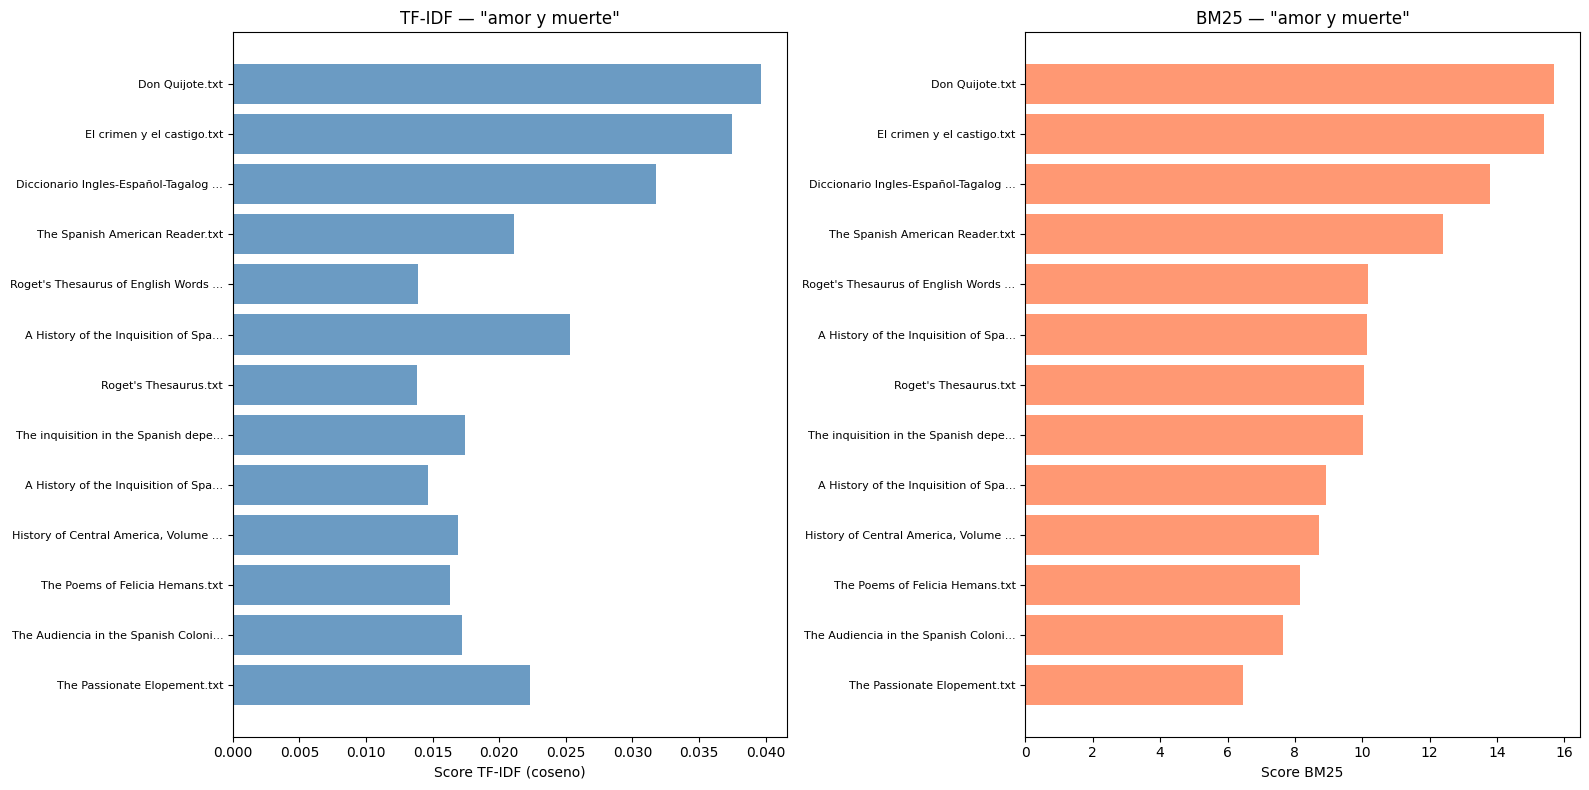


Gráfico guardado como comparacion_tfidf_bm25.png


In [22]:
# 4.1 Gráfico de barras comparativo: scores TF-IDF vs BM25
# Tomamos la unión de los top-10 de ambos modelos para comparar.

import matplotlib.pyplot as plt

# Recalcular TODOS los scores para poder compararlos
query_tokens = tokenizar(QUERY)
vector_query = tfidf_vectorizer.transform([QUERY])
todos_scores_tfidf = cosine_similarity(vector_query, matriz_tfidf).flatten()
todos_scores_bm25 = np.array([score_bm25_documento(query_tokens, i) for i in range(N)])

# Unión de top-10 de ambos modelos
top_tfidf_idx = set(np.argsort(todos_scores_tfidf)[::-1][:10])
top_bm25_idx = set(np.argsort(todos_scores_bm25)[::-1][:10])
union_idx = sorted(top_tfidf_idx | top_bm25_idx,
                   key=lambda i: todos_scores_tfidf[i] + todos_scores_bm25[i],
                   reverse=True)

# Preparar datos para el gráfico
labels = [nombres[i][:35] + '...' if len(nombres[i]) > 35 else nombres[i]
          for i in union_idx]
scores_tfidf_plot = [todos_scores_tfidf[i] for i in union_idx]
scores_bm25_plot = [todos_scores_bm25[i] for i in union_idx]

# Gráfico de barras horizontales
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, max(8, len(labels) * 0.4)))

y_pos = range(len(labels))

# Panel izquierdo: TF-IDF
ax1.barh(y_pos, scores_tfidf_plot, color='steelblue', alpha=0.8)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(labels, fontsize=8)
ax1.set_xlabel('Score TF-IDF (coseno)')
ax1.set_title(f'TF-IDF — "{QUERY}"')
ax1.invert_yaxis()

# Panel derecho: BM25
ax2.barh(y_pos, scores_bm25_plot, color='coral', alpha=0.8)
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels, fontsize=8)
ax2.set_xlabel('Score BM25')
ax2.set_title(f'BM25 — "{QUERY}"')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('comparacion_tfidf_bm25.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGráfico guardado como comparacion_tfidf_bm25.png')

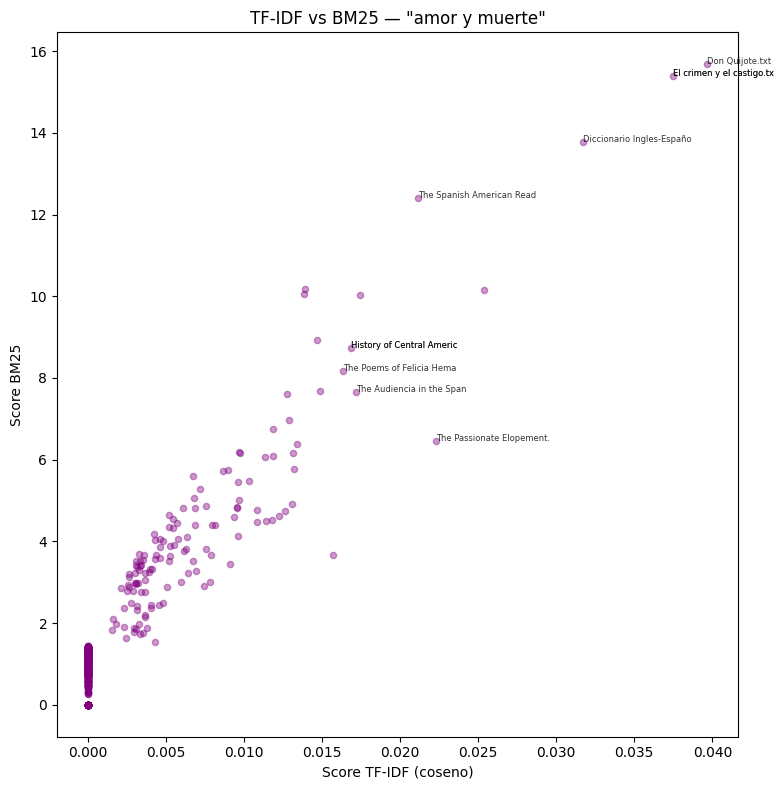

In [24]:
# 4.2 Scatter plot: TF-IDF vs BM25 score por documento
# Cada punto es un libro. Si ambos modelos coinciden, los puntos
# se alinean sobre la diagonal. Desviaciones muestran discrepancias.

fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(todos_scores_tfidf, todos_scores_bm25, alpha=0.4, s=20, color='purple')

# Etiquetar los top-5 de cada modelo
for i in list(top_tfidf_idx)[:5] + list(top_bm25_idx)[:5]:
    nombre_corto = nombres[i][:25]
    ax.annotate(nombre_corto,
                (todos_scores_tfidf[i], todos_scores_bm25[i]),
                fontsize=6, alpha=0.8)

ax.set_xlabel('Score TF-IDF (coseno)')
ax.set_ylabel('Score BM25')
ax.set_title(f'TF-IDF vs BM25 — "{QUERY}"')

plt.tight_layout()
plt.savefig('scatter_tfidf_bm25.png', dpi=150, bbox_inches='tight')
plt.show()

In [25]:
# 4.3 Análisis de cambios en el ranking
# ¿Qué documentos suben/bajan de posición al cambiar de TF-IDF a BM25?

# Ranking completo para ambos modelos
ranking_tfidf = np.argsort(todos_scores_tfidf)[::-1]
ranking_bm25 = np.argsort(todos_scores_bm25)[::-1]

# Crear mapa de posiciones: doc_idx → posición en el ranking
pos_tfidf = {doc_idx: pos for pos, doc_idx in enumerate(ranking_tfidf)}
pos_bm25 = {doc_idx: pos for pos, doc_idx in enumerate(ranking_bm25)}

# Calcular cambio de posición para los top-20 de la unión
union_top20 = sorted(
    set(list(ranking_tfidf[:20]) + list(ranking_bm25[:20])),
    key=lambda i: pos_tfidf[i]
)

print(f'Cambios de ranking para: "{QUERY}"')
print(f'{"Libro":<45} {"Pos TF-IDF":>10} {"Pos BM25":>10} {"Cambio":>8}')
print('-' * 80)

for i in union_top20[:15]:
    cambio = pos_tfidf[i] - pos_bm25[i]  # positivo = sube en BM25
    flecha = '↑' if cambio > 0 else ('↓' if cambio < 0 else '=')
    nombre_corto = nombres[i][:42]
    print(f'{nombre_corto:<45} {pos_tfidf[i]+1:>10} {pos_bm25[i]+1:>10} {flecha}{abs(cambio):>6}')

Cambios de ranking para: "amor y muerte"
Libro                                         Pos TF-IDF   Pos BM25   Cambio
--------------------------------------------------------------------------------
Don Quijote.txt                                        1          1 =     0
El crimen y el castigo.txt                             2          2 =     0
Diccionario Ingles-Español-Tagalog Con par             3          3 =     0
A History of the Inquisition of Spain vol.             4          6 ↓     2
The Passionate Elopement.txt                           5         17 ↓    12
The Spanish American Reader.txt                        6          4 ↑     2
The inquisition in the Spanish dependencie             7          8 ↓     1
The Audiencia in the Spanish Colonies As i             8         13 ↓     5
History of Central America, Volume 1, 1501             9         10 ↓     1
The Poems of Felicia Hemans.txt                       10         11 ↓     1
Erotica Romana.txt                       

In [28]:
# 4.4 Análisis: ¿por qué difieren TF-IDF y BM25?
# Verificamos la hipótesis: BM25 maneja mejor documentos de distinta
# longitud gracias a su normalización explícita.

# Para los documentos que más cambiaron de posición,
# veamos su longitud relativa al promedio.

print(f'Longitud promedio del corpus: {avgdl:,.0f} tokens\n')
print(f'{"Libro":<45} {"Tokens":>8} {"vs avg":>8} {"Pos TF":>7} {"Pos BM25":>9}')
print('-' * 85)

for i in union_top20[:15]:
    ratio = doc_lengths[i] / avgdl
    nombre_corto = nombres[i][:42]
    print(f'{nombre_corto:<45} {doc_lengths[i]:>8,} {ratio:>7.1f}x {pos_tfidf[i]+1:>7} {pos_bm25[i]+1:>9}')

print('\n' + '=' * 85)


Longitud promedio del corpus: 175,688 tokens

Libro                                           Tokens   vs avg  Pos TF  Pos BM25
-------------------------------------------------------------------------------------
Don Quijote.txt                                386,793     2.2x       1         1
El crimen y el castigo.txt                     181,078     1.0x       2         2
Diccionario Ingles-Español-Tagalog Con par     146,033     0.8x       3         3
A History of the Inquisition of Spain vol.     268,241     1.5x       4         6
The Passionate Elopement.txt                   113,618     0.6x       5        17
The Spanish American Reader.txt                121,256     0.7x       6         4
The inquisition in the Spanish dependencie     219,525     1.2x       7         8
The Audiencia in the Spanish Colonies As i     169,674     1.0x       8        13
History of Central America, Volume 1, 1501     321,287     1.8x       9        10
The Poems of Felicia Hemans.txt                4

**CONCLUSIONES:**

- TF-IDF con sublinear_tf ya aplica log(1+TF), pero NO normaliza
  explícitamente por longitud de documento (solo la norma L2 del vector).
- BM25 normaliza explícitamente: docs más largos que el promedio
  reciben una penalización controlada por el parámetro b.
- TF-IDF con normalización L2 tiende a favorecer documentos cortos
  (como "Erotica Romana" con 0.1x del promedio), donde pocas menciones
  pesan proporcionalmente más en el vector normalizado. BM25, en cambio,
  favorece documentos de longitud moderada que son densos en los términos
  de la query.
- La saturación de TF en BM25 (controlada por k1) también ayuda:
  después de cierto punto, más repeticiones no suman tanto score.

In [27]:
# EXTRA: Probar con otras consultas para ver si el patrón se mantiene

otras_consultas = [
    "guerra revolución España",
    "poesía romántica",
    "viaje América descubrimiento",
]

for q in otras_consultas:
    print(f'\n{"=" * 60}')
    print(f'Consulta: "{q}"')
    print(f'{"=" * 60}')

    r_tfidf = buscar_tfidf(q, top_k=5)
    r_bm25 = buscar_bm25(q, top_k=5)

    print(f'\n{"TF-IDF":<45} {"BM25":<45}')
    print('-' * 90)
    for i in range(5):
        t_libro = r_tfidf.iloc[i]['Libro'][:38]
        t_score = r_tfidf.iloc[i]['Score TF-IDF']
        b_libro = r_bm25.iloc[i]['Libro'][:38]
        b_score = r_bm25.iloc[i]['Score BM25']
        print(f'{t_libro:<38} ({t_score:.4f})  {b_libro:<38} ({b_score:.4f})')


Consulta: "guerra revolución España"

TF-IDF                                        BM25                                         
------------------------------------------------------------------------------------------
The Audiencia in the Spanish Colonies  (0.0534)  The Spanish American Reader.txt        (24.3234)
Don Quijote.txt                        (0.0344)  El crimen y el castigo.txt             (14.7057)
The Spanish American Reader.txt        (0.0342)  The Audiencia in the Spanish Colonies  (14.6679)
History of Central America, Volume 1,  (0.0334)  Don Quijote.txt                        (14.6183)
A History of the Inquisition of Spain  (0.0317)  History of Central America, Volume 1,  (13.9662)

Consulta: "poesía romántica"

TF-IDF                                        BM25                                         
------------------------------------------------------------------------------------------
Æsthetic as science of expression and  (0.0000)  Don Quijote.txt          